**Summary Statistics and Parameter Estimation**

Case Study: Temperature in Melaka Tengah

A survey was conducted to study day and night temperatures in Melaka Tengah. Temperatures (in the unit of Celsius) were recorded every 3 hours starting from 0200 to 2300 daily for 365 days.  

1) Download Melaka_Tengah.csv dataset

**Questions**

Q1) What are daily average temperatures in Melaka Tengah?
Q2) What is the median of Time 1100 and Time 1700? 
Q3) What is the sample mean of temperature in Melaka Tengah in 365 days?
Q4) What is the sample variance of temperature in Melaka Tengah in 365 days?
Q5) What is the confidence interval for the variance of mean temperature? 


In [2]:
#import a datafile into Python
#Use Pandas

In [3]:
#Q1) What are daily average temperatures in Melaka Tengah?

import pandas as pd

data = pd.read_csv('Melaka_Tengah.csv')
#the entire data
print(data)
print()

     Time 0200  Time 0500  Time 0800  Time 1100  Time 1400  Time 1700  \
0         28.2       27.1       26.3       25.0       24.3       26.6   
1         28.9       27.9       27.0       25.7       25.1       27.4   
2         28.3       27.2       26.4       25.1       24.5       26.9   
3         28.4       27.3       26.5       25.2       24.6       27.1   
4         28.6       27.5       26.6       25.4       24.8       27.3   
..         ...        ...        ...        ...        ...        ...   
360       29.1       28.0       27.2       26.0       25.3       27.5   
361       28.7       27.6       26.8       25.6       24.9       27.2   
362       28.8       27.7       26.9       25.7       24.9       27.4   
363       28.9       27.8       27.0       25.8       25.0       27.6   
364       28.8       27.7       26.9       25.7       25.0       27.6   

     Time 2000  Time 2300  
0         27.7       26.9  
1         28.5       27.7  
2         27.7       27.1  
3         2

In [4]:
df = pd.DataFrame(data, columns=['Time 0200', 'Time 0500'])
print(df)

     Time 0200  Time 0500
0         28.2       27.1
1         28.9       27.9
2         28.3       27.2
3         28.4       27.3
4         28.6       27.5
..         ...        ...
360       29.1       28.0
361       28.7       27.6
362       28.8       27.7
363       28.9       27.8
364       28.8       27.7

[365 rows x 2 columns]


In [5]:
#average for each row ; vertical
daily_average = data.mean(axis=1)
print(daily_average)

0      26.5125
1      27.2750
2      26.6500
3      26.7625
4      26.9250
        ...   
360    27.4750
361    27.0750
362    27.1500
363    27.2500
364    27.1875
Length: 365, dtype: float64


In [6]:
#average for each row ; average for every time frame
daily_average = data.mean(axis=0)
print(daily_average)

Time 0200    28.743288
Time 0500    27.638904
Time 0800    26.829589
Time 1100    25.557260
Time 1400    24.927671
Time 1700    27.298082
Time 2000    28.186301
Time 2300    27.529589
dtype: float64


In [7]:
#Q2) What is the median of Time 1100 and Time 1700? 
#average for two selected column
print(data[['Time 1100', 'Time 1700']].mean())

Time 1100    25.557260
Time 1700    27.298082
dtype: float64


In [8]:
#mean
print("The average of temperature in Melaka Tengah in 365 days is %.2f" %daily_average.mean())
#variance
print("The variance in Melaka Tengah in 365 days is %.2f" %daily_average.var())

The average of temperature in Melaka Tengah in 365 days is 27.09
The variance in Melaka Tengah in 365 days is 1.65


In [9]:
#Q2) What is the median of Time 1100 and Time 1700? 
#Descriptive/Summary Statistics
print("Medians: ")
print(data[['Time 1100', 'Time 1700']].median())

Medians: 
Time 1100    25.6
Time 1700    27.4
dtype: float64


In [10]:
print(data[['Time 1100', 'Time 1700']].describe())

        Time 1100   Time 1700
count  365.000000  365.000000
mean    25.557260   27.298082
std      0.357776    0.470996
min     24.300000   25.700000
25%     25.400000   27.100000
50%     25.600000   27.400000
75%     25.800000   27.600000
max     26.500000   28.300000


In [11]:
print(daily_average.describe())

count     8.000000
mean     27.088836
std       1.285403
min      24.927671
25%      26.511507
50%      27.413836
75%      27.775753
max      28.743288
dtype: float64


#Q2) What is the median of Time 1100 and Time 1700? 
#Selecting Some Summary Statistics, Use DataFrame.agg() method

In [12]:
statistics = data.agg({"Time 1100": ["min","max","median","skew"],
                       "Time 1700": ["min","max","median","mean"]})
print(statistics)

        Time 1100  Time 1700
min     24.300000  25.700000
max     26.500000  28.300000
median  25.600000  27.400000
skew    -0.412059        NaN
mean          NaN  27.298082


Mean: 27.09


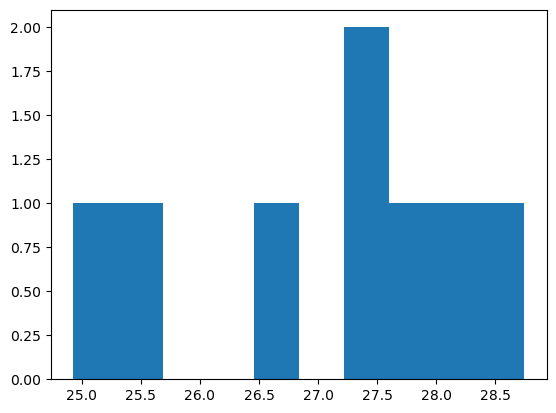

In [13]:
daily_average.hist(grid=False)
temp_mean = daily_average.mean()
print("Mean: %.2f" %temp_mean)

Time 0200    28.743288
Time 0500    27.638904
Time 0800    26.829589
Time 1100    25.557260
Time 1400    24.927671
Time 1700    27.298082
Time 2000    28.186301
Time 2300    27.529589
dtype: float64


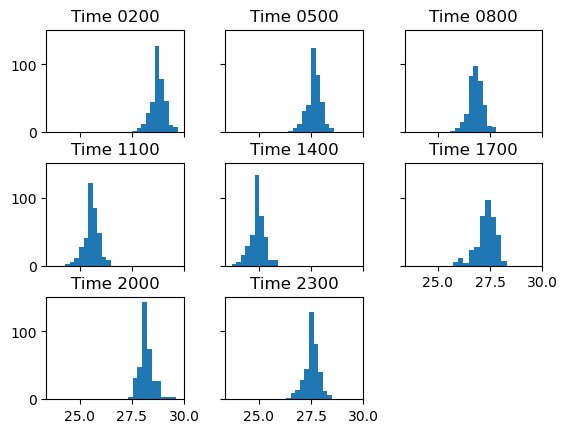

In [14]:
#Parameter Estimation
#In parametric inference, we first find a suitable distribution,
#and choose the parameters that best represent the data.

import pandas as pd 
data = pd.read_csv("Melaka_Tengah.csv")

data.hist(sharex=True, sharey=True, grid=False)
print(data.mean())

In [15]:
#Parameter Estimation
#In parametric inference, we first find a suitable distribution,
#and choose the parameters that best represent the data.


In [16]:
#Mean Intreval Estimation
import pandas as pd
import numpy as np
import scipy.stats as st

data = pd.read_csv("Melaka_Tengah.csv")
daily_average = data.mean(axis=1)

# create 95% confidence interval for population mean temperature
mean_interval = st.norm.interval(confidence=0.95,
                                 loc=np.mean(daily_average),
                                 scale=st.sem(daily_average))
print("(%.2f \t %.2f)" %mean_interval)

#there is a 95% chance that the confidence interval of (27.05  27.13) contains the true population mean temperature


(27.05 	 27.13)


References: 
https://www.geeksforgeeks.org/getting-started-with-python-programming/?ref=shm
https://medium.com/@nishantbhushan10/python-lists-tuples-sets-dictionary-a9cbcac183e3
https://hackr.io/blog/python-data-structures
